## Random Forest ML model on Predicting the required drug for a patient (Drug Dataset) from kaggle by Keshav Verma

importing the required libraries and modules

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt

I have uploaded the dataset on google drive and made it public and thereafter fetched the dataset in colab notebook using the following method

In [ ]:
# https://drive.google.com/file/d/1Tu2BWiT-ncpTw_mvq8-JBYpOzZ-8BZCT/view?usp=sharing

# Replacing FILE_ID with the actual ID from your link
# The FILE_ID is the part between /d/ and /view

file_id = "1Tu2BWiT-ncpTw_mvq8-JBYpOzZ-8BZCT"
file_url = f"https://drive.google.com/uc?id={file_id}"

loading the dataset

In [ ]:
# Load the dataset
df = pd.read_csv(file_url)

printing the structure of the dataset and first few entries

In [ ]:
df.info() # printing the summary of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [ ]:
df.head(10)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
5,22,F,NORMAL,HIGH,8.607,drugX
6,49,F,NORMAL,HIGH,16.275,drugY
7,41,M,LOW,HIGH,11.037,drugC
8,60,M,NORMAL,HIGH,15.171,drugY
9,43,M,LOW,NORMAL,19.368,drugY


data encoding

In [ ]:
# Encode categorical features
label_encoders = {}
for col in ['Sex', 'BP', 'Cholesterol', 'Drug']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Split dataset into features and target variable
X = df.drop(columns=['Drug'])
y = df['Drug']

data splitting and then model training

In [ ]:
# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', random_state=42)

predicting and evaluating the model

In [ ]:
# Predictions and evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:\n', classification_report(y_test, y_pred))

Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00        15

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [ ]:
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
print("Confusion Matrix: \n", cm, "\n")
print("Classification Report: \n", report)
print("Accuracy: ", accuracy)

Confusion Matrix: 
 [[ 6  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0 15]] 

Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00        15

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Accuracy:  1.0


feature importance visualisation

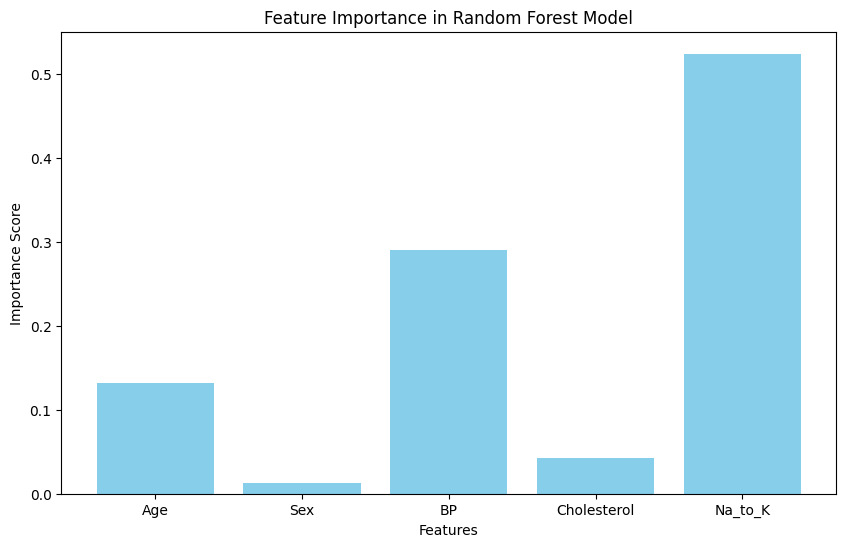

In [ ]:
# Feature Importance Visualization
feature_importances = model.feature_importances_
plt.figure(figsize=(10, 6))
plt.bar(X.columns, feature_importances, color='skyblue')
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance in Random Forest Model")
plt.show()

## * I have first uploaded the dataset file on google drive
## https://drive.google.com/file/d/1Tu2BWiT-ncpTw_mvq8-JBYpOzZ-8BZCT/view?usp=sharing
* Made this dataset file public (anyone to view)
* Fetched this dataset file from google drive to google colab notebook by
** FILE_ID is the part between /d/ and /view of the link of the dataset
** Replacing FILE_ID with the actual ID from our link
** file_id = "File_Id_here"
** file_url = f"https://drive.google.com/uc?id={file_id}"
## dataset = pandas.read	_csv(file_url)